In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from google.colab import drive
from zipfile import ZipFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from collections import defaultdict

# VGG13

In [2]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

batch_size = 64
learning_rate = 1e-3
weight_decay = 1e-4

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
CLS = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
NUM_CLS = len(CLS)
CLS_DICT = {cl:i for i, cl in enumerate(CLS)}
CLS_DICT

{'neutral': 0,
 'happiness': 1,
 'surprise': 2,
 'sadness': 3,
 'anger': 4,
 'disgust': 5,
 'fear': 6,
 'contempt': 7}

In [5]:
def extract_fer_datasets():
    drive.mount('/content/drive')

    base_path = '/content/drive/MyDrive/ml/projekt/fer2013'

    target_dirs_exist = any(os.path.isdir(d) for d in ['FER2013Test', 'FER2013Train', 'FER2013Valid'])

    if not target_dirs_exist:
        zip_file_path = os.path.join(base_path, 'data.zip')
        extract_path = '/content/'

        if os.path.exists(zip_file_path):
            with ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
            print(f"Extracted {zip_file_path} to {extract_path}")
        else:
            print(f"Zip file not found at: {zip_file_path}")
    else:
        print("Dataset already extracted")

In [6]:
class FerPlusDataset(Dataset):
    def __init__(self, split, transform, mode='mv', theta=0.3):
        if os.path.exists('/content/drive/MyDrive/ml/projekt/fer2013/data.zip'):
            self.root = f'FER2013{split}'
        else:
            self.root = f'/content/drive/MyDrive/ml/projekt/fer2013/FER2013{split}'
        self.transform = transform
        self.mode = mode
        self.theta = theta

        column_names = [
            'image_name', 'image_tensor',
            'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt',
            'unknown', 'NF'
        ]

        df = pd.read_csv(os.path.join(self.root, 'label.csv'), names=column_names, header=None)
        df = df[['image_name', 'neutral', 'happiness',
                 'surprise', 'sadness', 'anger',
                 'disgust', 'fear', 'contempt']]

        self.labels = df[CLS].values
        self.images = df['image_name'].values

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.images[idx])
        img = Image.open(img_path)
        x = self.transform(img)

        p = self.labels[idx]
        p = np.nan_to_num(p)

        if self.mode == 'mv':
            y = torch.tensor(np.argmax(p), dtype = torch.long)

        elif self.mode == 'pld':
            sum_p = np.sum(p)
            if sum_p == 0:
                p = np.ones(NUM_CLS) / NUM_CLS
            else:
                p = p / sum_p

            if np.isnan(p).any() or np.isinf(p).any():
                 p = np.ones(NUM_CLS) / NUM_CLS

            y = torch.tensor(np.random.choice(NUM_CLS, p=p), dtype = torch.long)

        elif self.mode == "cel":
            sum_p = np.sum(p)
            if sum_p == 0:
                p = np.ones(NUM_CLS) / NUM_CLS
            else:
                p = p / sum_p

            if np.isnan(p).any() or np.isinf(p).any():
                 p = np.ones(NUM_CLS) / NUM_CLS

            y = torch.tensor(p, dtype=torch.float32)

        elif self.mode == "ml":
            mask = (p / 10.0) > self.theta
            if not mask.any():
                mask[np.argmax(p)] = 1
            y = torch.tensor(mask, dtype=torch.float32)

        else:
            raise ValueError(f"Unknown mode {self.mode}")

        return x, y

In [7]:
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

val_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [8]:
def make_loaders(mode):
    train_ds = FerPlusDataset(split='Train', transform=train_tf, mode=mode)
    val_ds = FerPlusDataset(split='Valid', transform=train_tf, mode=mode)
    test_ds = FerPlusDataset(split='Test', transform=train_tf, mode=mode)

    return (
        DataLoader(train_ds, batch_size=batch_size,
                   shuffle=True, num_workers=1,
                   pin_memory=torch.cuda.is_available()),
        DataLoader(val_ds, batch_size=batch_size,
                   shuffle=False, num_workers=1,
                   pin_memory=torch.cuda.is_available()),
        DataLoader(test_ds, batch_size=batch_size,
                   shuffle=False, num_workers=1,
                   pin_memory=torch.cuda.is_available()),
    )

In [9]:
def make_model():
    model = models.vgg13_bn(weights=models.VGG13_BN_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, NUM_CLS)
    return model.to(device)

In [10]:
def get_loss(mode):
    if mode in ('mv','pld'):
        return nn.CrossEntropyLoss()
    elif mode == 'cel':
        return nn.KLDivLoss(reduction="batchmean")
    elif mode == 'ml':
        return nn.BCEWithLogitsLoss()
    else:
        raise ValueError(f"Unknown mode {mode}")

In [11]:
def run_epoch(model, loader, criterion, mode, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    loss_total = 0
    correct = 0
    total = 0

    with torch.set_grad_enabled(train):
        for data, target in tqdm(loader, desc="Training" if train else "Validation"):
              data, target = data.to(device), target.to(device)

              if train:
                  optimizer.zero_grad()

              output = model(data)

              if mode == 'cel':
                  loss = criterion(torch.log_softmax(output, dim=1), target)
              else:
                  loss = criterion(output, target)

              if train:
                  loss.backward()
                  optimizer.step()

              if mode == 'ml':
                  preds = (torch.sigmoid(output) > 0.5).int()
                  targs = target.int()
                  correct += (preds & targs).sum().item()
                  total += targs.sum().item()
              else:  # mv, pld, cel
                  preds = output.argmax(1)
                  if mode == 'cel':
                      targs = target.argmax(1)
                  else:  # mv / pld
                      targs = target
                  correct += (preds == targs).sum().item()
                  total += targs.size(0)

              loss_total += loss.item()

    avg_loss = loss_total / len(loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy

In [12]:
def history_plot(train_losses,val_losses,train_accs,val_accs):
      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
      ax1.plot(train_losses, label='Train Loss')
      ax1.plot(val_losses, label='Val Loss')
      ax1.set_xlabel('Epoch')
      ax1.set_ylabel('Loss')
      ax1.set_title('Training and Validation Loss')
      ax1.legend()
      ax1.grid(True)

      ax2.plot(train_accs, label='Train Acc')
      ax2.plot(val_accs, label='Val Acc')
      ax2.set_xlabel('Epoch')
      ax2.set_ylabel('Accuracy (%)')
      ax2.set_title('Training and Validation Accuracy')
      ax2.legend()
      ax2.grid(True)

      plt.tight_layout()
      plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
      plt.show()


In [13]:
def train_model(mode):
    extract_fer_datasets()

    train_loader, val_loader, test_loader = make_loaders(mode)
    print(f"Train samples: {len(train_loader.dataset)}")
    print(f"Val samples: {len(val_loader.dataset)}")
    print(f"Test samples: {len(test_loader.dataset)}")

    model = make_model()

    criterion = get_loss(mode)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    patience = 3
    best_val_acc = 0
    patience_counter = 0

    checkpoint_path = f'/content/drive/MyDrive/ml/projekt/best_model_{mode}.pth'
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_acc = checkpoint['best_val_acc']
        print(f"Resuming from epoch {start_epoch}")

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    num_epochs = 10
    for epoch in range(num_epochs):
          print(f"\nEpoch {epoch+1}/{num_epochs}")
          print('-'*50)

          train_loss, train_acc = run_epoch(model, train_loader, criterion, mode, optimizer, train=True)
          val_loss, val_acc = run_epoch(model, val_loader, criterion, mode, train=False)

          scheduler.step()

          train_losses.append(train_loss)
          val_losses.append(val_loss)
          train_accs.append(train_acc)
          val_accs.append(val_acc)

          print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
          print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
          print(f'Learning Rate: {scheduler.get_last_lr()[0]:.6f}')

          if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_val_acc': best_val_acc,
                }, checkpoint_path)
                print(f'New best model saved with val accuracy: {best_val_acc:.2f}%')

          else:
                patience_counter += 1
                if patience_counter >= patience:
                    print("Early stopping")
                    break

    history_plot(train_losses, val_losses, train_accs, val_accs)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted
Train samples: 28558
Val samples: 3579
Test samples: 3573

Epoch 1/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.49it/s]


Train Loss: 0.9983, Train Acc: 65.68%
Val Loss: 0.8700, Val Acc: 68.26%
Learning Rate: 0.001000
New best model saved with val accuracy: 68.26%

Epoch 2/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.44it/s]


Train Loss: 0.7912, Train Acc: 72.55%
Val Loss: 0.9509, Val Acc: 69.21%
Learning Rate: 0.001000
New best model saved with val accuracy: 69.21%

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.5256, Train Acc: 81.20%
Val Loss: 1.7993, Val Acc: 63.09%
Learning Rate: 0.001000

Epoch 9/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.47it/s]



Train Loss: 0.5108, Train Acc: 81.74%
Val Loss: 0.7055, Val Acc: 76.70%
Learning Rate: 0.001000

Epoch 10/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.49it/s]



Train Loss: 0.4838, Train Acc: 82.69%
Val Loss: 0.6071, Val Acc: 79.66%
Learning Rate: 0.000100
New best model saved with val accuracy: 79.66%


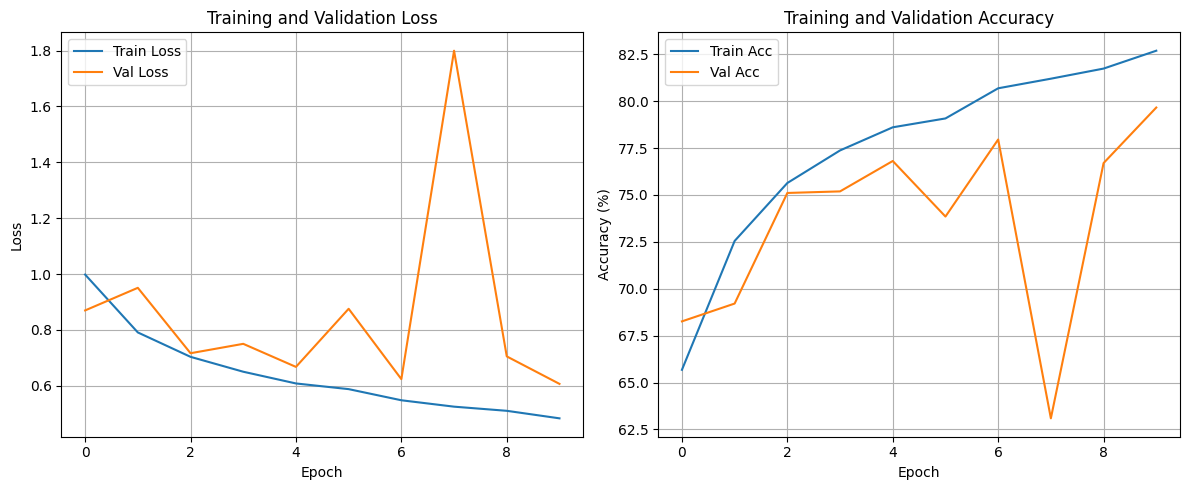

In [ ]:
train_model('mv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted
Train samples: 28558
Val samples: 3579
Test samples: 3573

Epoch 1/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.38it/s]


Train Loss: 1.3919, Train Acc: 50.89%
Val Loss: 1.1842, Val Acc: 59.99%
Learning Rate: 0.001000
New best model saved with val accuracy: 59.99%

Epoch 2/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.40it/s]


Train Loss: 1.1816, Train Acc: 59.50%
Val Loss: 1.1230, Val Acc: 61.94%
Learning Rate: 0.001000
New best model saved with val accuracy: 61.94%

Epoch 3/10
--------------------------------------------------


...

Train Loss: 1.0156, Train Acc: 65.26%
Val Loss: 0.9393, Val Acc: 67.95%
Learning Rate: 0.001000
New best model saved with val accuracy: 67.95%

Epoch 9/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.38it/s]


Train Loss: 0.9907, Train Acc: 66.21%
Val Loss: 0.9795, Val Acc: 66.39%
Learning Rate: 0.001000

Epoch 10/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.39it/s]


Train Loss: 0.9828, Train Acc: 66.69%
Val Loss: 0.9361, Val Acc: 67.98%
Learning Rate: 0.000100
New best model saved with val accuracy: 67.98%


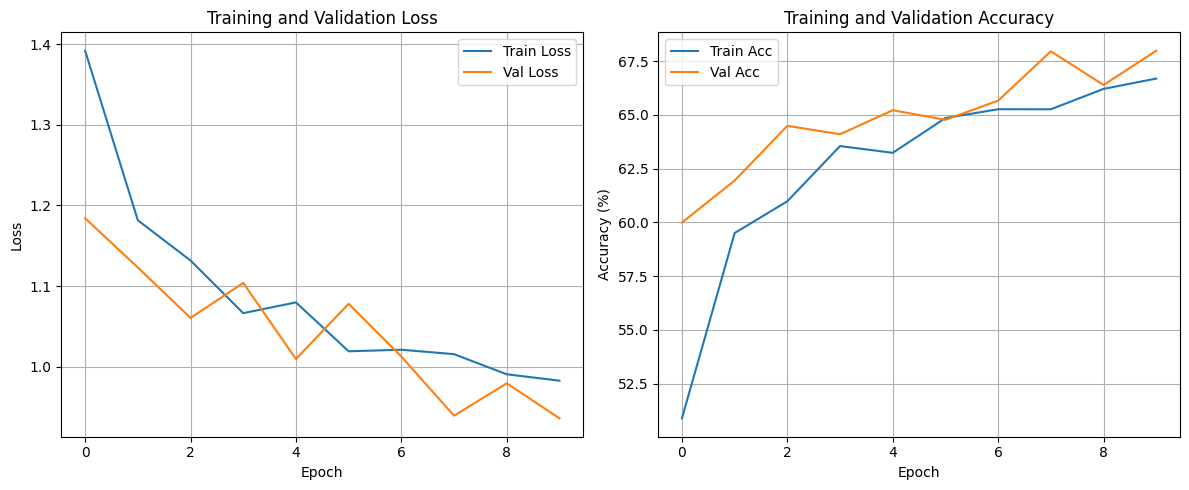

In [ ]:
train_model('pld')

Mounted at /content/drive
Extracted /content/drive/MyDrive/ml/projekt/fer2013/data.zip to /content/
Train samples: 28558
Val samples: 3579
Test samples: 3573


Downloading: "https://download.pytorch.org/models/vgg13_bn-abd245e5.pth" to /root/.cache/torch/hub/checkpoints/vgg13_bn-abd245e5.pth
100%|██████████| 508M/508M [00:08<00:00, 62.5MB/s]



Epoch 1/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.45it/s]


Train Loss: 0.7445, Train Acc: 62.44%
Val Loss: 0.6155, Val Acc: 69.21%
Learning Rate: 0.001000
New best model saved with val accuracy: 69.21%

Epoch 2/10
--------------------------------------------------


...

Train Loss: 0.3620, Train Acc: 80.38%
Val Loss: 0.4012, Val Acc: 79.27%
Learning Rate: 0.001000
New best model saved with val accuracy: 79.27%

Epoch 9/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.41it/s]


Train Loss: 0.3539, Train Acc: 80.82%
Val Loss: 0.4065, Val Acc: 80.05%
Learning Rate: 0.001000
New best model saved with val accuracy: 80.05%

Epoch 10/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.49it/s]


Train Loss: 0.3470, Train Acc: 81.14%
Val Loss: 0.3878, Val Acc: 78.71%
Learning Rate: 0.000100


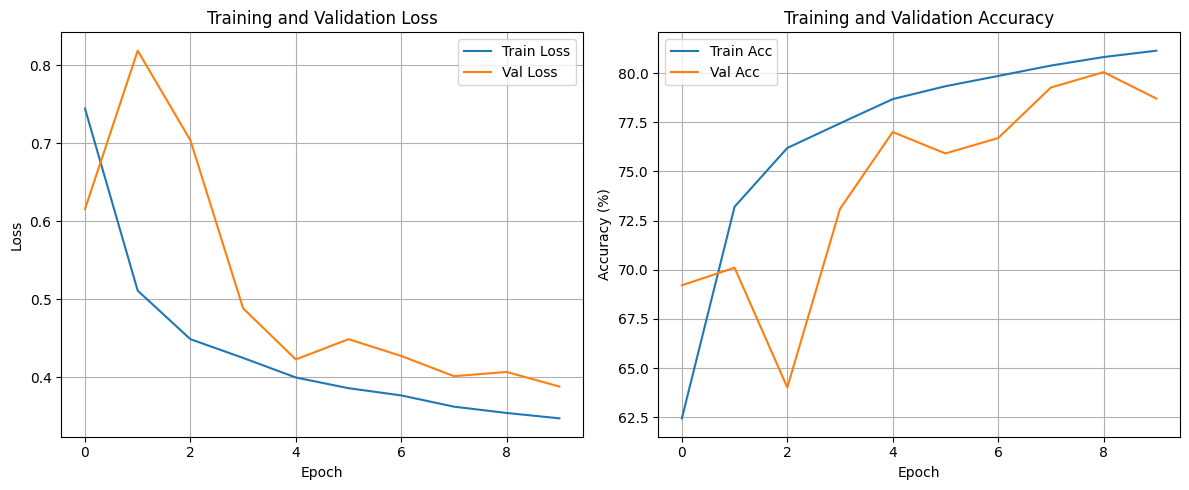

In [ ]:
train_model('cel')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted
Train samples: 28558
Val samples: 3579
Test samples: 3573

Epoch 1/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.48it/s]


Train Loss: 0.2215, Train Acc: 53.88%
Val Loss: 0.3714, Val Acc: 58.58%
Learning Rate: 0.001000
New best model saved with val accuracy: 58.58%

Epoch 2/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:16<00:00,  3.41it/s]


Train Loss: 0.1875, Train Acc: 63.44%
Val Loss: 0.1947, Val Acc: 62.08%
Learning Rate: 0.001000
New best model saved with val accuracy: 62.08%

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.1409, Train Acc: 74.40%
Val Loss: 0.1500, Val Acc: 72.72%
Learning Rate: 0.001000

Epoch 9/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:15<00:00,  3.55it/s]


Train Loss: 0.1366, Train Acc: 75.45%
Val Loss: 0.1660, Val Acc: 73.34%
Learning Rate: 0.001000
New best model saved with val accuracy: 73.34%

Epoch 10/10
--------------------------------------------------


Validation: 100%|██████████| 56/56 [00:15<00:00,  3.52it/s]


Train Loss: 0.1339, Train Acc: 75.75%
Val Loss: 0.1440, Val Acc: 75.90%
Learning Rate: 0.000100
New best model saved with val accuracy: 75.90%


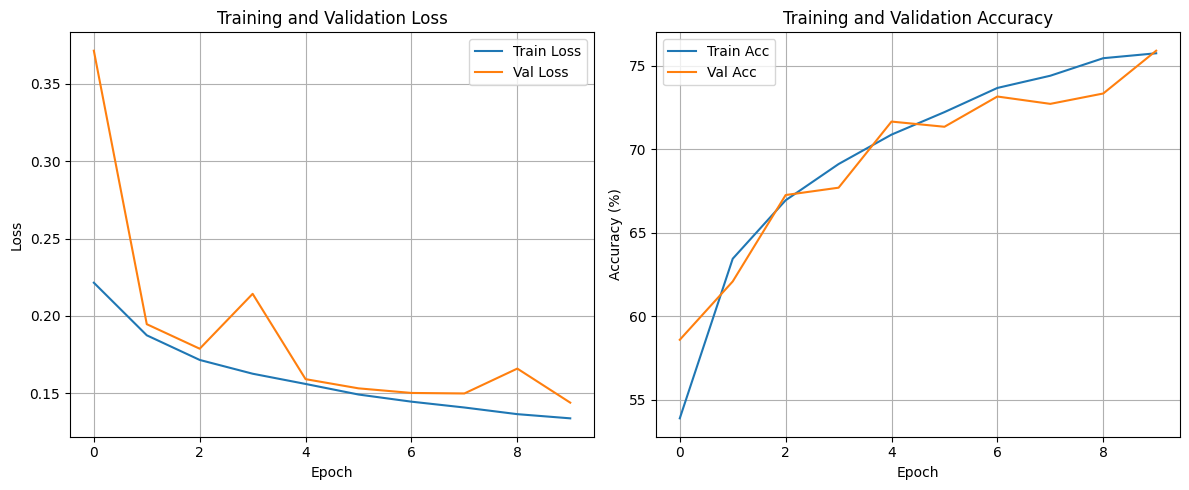

In [ ]:
train_model('ml')

# MobileNet V2 + Triplet Loss

In [14]:
class MobileNetTriplet(nn.Module):
    def __init__(self, emb_dim=128, num_cls=NUM_CLS):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.emb = nn.Linear(1280, emb_dim)
        self.classifier = nn.Linear(emb_dim, num_cls)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).view(x.size(0), -1)
        emb = F.normalize(self.emb(x), p=2, dim=1)
        logits = self.classifier(emb)
        return emb, logits

In [15]:
def random_triplets(embeddings, labels):
    anchors, positives, negatives = [], [], []
    labels = labels.cpu().numpy()

    for i, lbl in enumerate(labels):
        pos_idx = np.where(labels == lbl)[0]
        neg_idx = np.where(labels != lbl)[0]
        if len(pos_idx) > 1 and len(neg_idx):
            p = np.random.choice(pos_idx[pos_idx != i])
            n = np.random.choice(neg_idx)
            anchors.append(i)
            positives.append(p)
            negatives.append(n)

    return (embeddings[anchors], embeddings[positives], embeddings[negatives])

In [16]:
def run_epoch_triplet(model, loader, triplet_loss, ce_loss, optimizer=None, train=True):
    phase = "Training" if train else "Validation"
    model.train() if train else model.eval()

    loss_tot, acc_tot, n_tot = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for data, targets in tqdm(loader, desc=phase):
            data, targets = data.to(device), targets.to(device)
            if train:
                optimizer.zero_grad()

            embs, logits = model(data)

            anc, pos, neg = random_triplets(embs, targets)
            if len(anc) == 0:
                continue
            loss_t = triplet_loss(anc, pos, neg)
            loss_ce = ce_loss(logits, targets)
            loss = loss_t + loss_ce

            if train:
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            acc_tot += (preds == targets).sum().item()
            n_tot  += targets.size(0)
            loss_tot += loss.item()

    return loss_tot / len(loader), 100. * acc_tot / n_tot

In [17]:
def train_mobilenet_triplet():
    extract_fer_datasets()

    train_loader, val_loader, _ = make_loaders('mv')
    print(f"Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

    model = MobileNetTriplet().to(device)

    triplet_loss = nn.TripletMarginLoss(margin=0.2)
    ce_loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_acc, patience, patience_ctr = 0, 3, 0
    ckpt_path = '/content/drive/MyDrive/ml/projekt/best_model_triplet.pth'

    hist = {'tr_loss':[], 'val_loss':[], 'tr_acc':[], 'val_acc':[]}

    num_epochs = 30
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}\n" + '-'*40)
        train_loss, train_acc = run_epoch_triplet(model, train_loader, triplet_loss, ce_loss, optimizer, train=True)
        val_loss, val_acc = run_epoch_triplet(model, val_loader, triplet_loss, ce_loss, train=False)

        scheduler.step()

        for k,v in zip(('tr_loss','val_loss','tr_acc','val_acc'),
                       (train_loss, val_loss, train_acc, val_acc)):
            hist[k].append(v)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Learning Rate: {scheduler.get_last_lr()[0]:.6f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save({'epoch':epoch,
                        'model_state_dict':model.state_dict(),
                        'optimizer_state_dict':optimizer.state_dict(),
                        'best_val_acc':best_val_acc},
                       ckpt_path)
            print(f'New best model saved with val accuracy: {best_val_acc:.2f}%')
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print("Early stopping!")
                break

    history_plot(hist['tr_loss'], hist['val_loss'], hist['tr_acc'], hist['val_acc'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted
Train: 28558, Val: 3579

Epoch 1/30
----------------------------------------


Validation: 100%|██████████| 56/56 [00:10<00:00,  5.31it/s]


Train Loss: 1.2825, Train Acc: 65.34%
Val Loss: 0.9511, Val Acc: 72.14%
Learning Rate: 0.001000
New best model saved with val accuracy: 72.14%

Epoch 2/30
----------------------------------------


Validation: 100%|██████████| 56/56 [00:09<00:00,  6.16it/s]


Train Loss: 0.8957, Train Acc: 73.62%
Val Loss: 0.8791, Val Acc: 73.01%
Learning Rate: 0.001000
New best model saved with val accuracy: 73.01%

Epoch 3/30
----------------------------------------


...

Train Loss: 0.3362, Train Acc: 89.95%
Val Loss: 0.6178, Val Acc: 81.73%
Learning Rate: 0.001000

Epoch 15/30
----------------------------------------


Validation: 100%|██████████| 56/56 [00:08<00:00,  6.42it/s]


Train Loss: 0.3197, Train Acc: 90.39%
Val Loss: 0.6335, Val Acc: 81.78%
Learning Rate: 0.001000

Epoch 16/30
----------------------------------------


Validation: 100%|██████████| 56/56 [00:09<00:00,  5.92it/s]


Train Loss: 0.2992, Train Acc: 91.24%
Val Loss: 0.6367, Val Acc: 81.45%
Learning Rate: 0.001000
Early stopping!


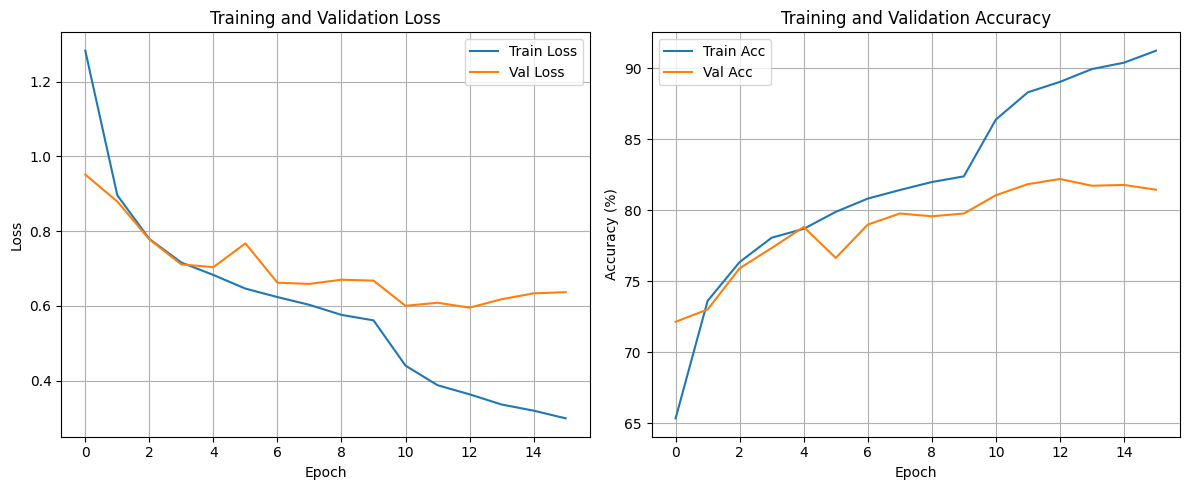

In [ ]:
train_mobilenet_triplet()

In [18]:
def _eval_triplet(model, loader):
    model.eval()
    ce = nn.CrossEntropyLoss()
    loss_tot, corr, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Test-triplet"):
            x, y = x.to(device), y.to(device)
            _, logits = model(x)
            loss_tot += ce(logits, y).item()
            corr += (logits.argmax(1) == y).sum().item()
            n    += y.size(0)
    return loss_tot / len(loader), 100.*corr / n


def evaluate_all_models():
    extract_fer_datasets()

    modes_vgg = ['mv', 'pld', 'cel', 'ml']
    results   = {}

    for mode in modes_vgg:
        ckpt = f'/content/drive/MyDrive/ml/projekt/best_model_{mode}.pth'
        model = make_model()
        model.load_state_dict(torch.load(ckpt, map_location=device)['model_state_dict'])
        model.to(device)

        test_loader = make_loaders(mode)[2]
        criterion   = get_loss(mode)

        loss, acc = run_epoch(model, test_loader, criterion,
                              mode=mode, train=False)
        results[mode] = {'loss': loss, 'acc': acc}

    ckpt_t   = '/content/drive/MyDrive/ml/projekt/best_model_triplet.pth'
    model_t  = MobileNetTriplet().to(device)
    model_t.load_state_dict(torch.load(ckpt_t, map_location=device)['model_state_dict'])

    test_loader_t = make_loaders('mv')[2]
    loss_t, acc_t = _eval_triplet(model_t, test_loader_t)
    results['triplet'] = {'loss': loss_t, 'acc': acc_t}

    df = (pd.DataFrame(results)
            .T.assign(acc=lambda d: d['acc'].round(2),
                       loss=lambda d: d['loss'].round(4))
            .sort_values('acc', ascending=False))
    display(df)
    print("\nTest-set accuracy (%):")
    for m, row in df.iterrows():
        print(f"{m:>8}  {row['acc']:6.2f}  (loss={row['loss']})")

    return results

In [19]:
evaluate_all_models()

Mounted at /content/drive
Extracted /content/drive/MyDrive/ml/projekt/fer2013/data.zip to /content/


Downloading: "https://download.pytorch.org/models/vgg13_bn-abd245e5.pth" to /root/.cache/torch/hub/checkpoints/vgg13_bn-abd245e5.pth
100%|██████████| 508M/508M [00:04<00:00, 127MB/s]
Validation: 100%|██████████| 56/56 [00:17<00:00,  3.25it/s]
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 215MB/s]
Test-triplet: 100%|██████████| 56/56 [00:09<00:00,  5.74it/s]


,loss,acc
triplet,0.5692,81.95
mv,0.6174,78.34
cel,0.4095,78.11
ml,0.1454,75.14
pld,0.9768,66.61



Test-set accuracy (%):
 triplet   81.95  (loss=0.5692)
      mv   78.34  (loss=0.6174)
     cel   78.11  (loss=0.4095)
      ml   75.14  (loss=0.1454)
     pld   66.61  (loss=0.9768)


{'mv': {'loss': 0.617414371243545, 'acc': 78.33753148614609},
 'pld': {'loss': 0.9767640339476722, 'acc': 66.61069129582984},
 'cel': {'loss': 0.4095294826797077, 'acc': 78.11363000279877},
 'ml': {'loss': 0.14538265259138175, 'acc': 75.14182568334193},
 'triplet': {'loss': 0.5691752880811691, 'acc': 81.94794290512175}}